In [1]:
!hostname

node114


In [1]:
import pickle as pkl
import pandas as pd
import numpy as np
from pathlib import Path

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from src import util_analysis 
from src import util_process_prolific as util_process
import re

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


## Get participant data for current pipeline

In [2]:
def get_target_transcript(fname):
    return df_w_transcripts.loc[df_w_transcripts['targ_src_stem'].eq(fname), 'target_transcripts'].values[0]

def get_distractor_tscript(fname):
    if df_w_transcripts['dist_1_src_stem'].eq(fname).any():
        tscript = df_w_transcripts.loc[df_w_transcripts['dist_1_src_stem'].eq(fname), 'distractor_1_transcripts'].values[0]
    elif df_w_transcripts['dist_2_src_stem'].eq(fname).any():
        tscript = df_w_transcripts.loc[df_w_transcripts['dist_2_src_stem'].eq(fname), 'distractor_2_transcripts'].values[0]
    return tscript

def get_part_manifest_dict(manifest_file_name):
    part_manifest = pd.read_pickle(manifest_file_name)
    records = []
    trial_ix_count = 0 
    for block_name, block in part_manifest.items():
        for trial_ix, trial_dict in block.items():
            trial_dict['trial_num'] = trial_ix_count
            trial_dict['target_azimuth'] = trial_dict['target_loc'][0] 
            trial_dict['target_elev'] = trial_dict['target_loc'][1]
            trial_dict['distractor_azimuth'] = trial_dict['distractor_loc'][0]
            trial_dict['distractor_elev'] = trial_dict['distractor_loc'][1]
            trial_dict['block_name'] = block_name
            records.append(trial_dict)
            trial_ix_count += 1
    manifest_df = pd.DataFrame(records)
    manifest_df.drop(columns=['target_loc', 'distractor_loc', 'distractor_word'], inplace=True)
    return manifest_df

In [3]:
#### Load in experiment manifests with full transcripts
parent_dir = Path("/om/user/imgriff/datasets/human_word_rec_SWC_2024/")
manifest = pd.read_pickle(parent_dir / "full_cue_target_distractor_df_w_meta_paths.pdpkl")

path_to_manifest = Path('/om/user/imgriff/datasets/human_word_rec_SWC_2024/full_cue_target_distractor_df_w_meta_transcripts.pdpkl')
df_w_transcripts = pd.read_pickle(path_to_manifest)

# unpack distractor words to individual columns

dist_1_word, dist_2_word = zip(*df_w_transcripts.distractor_word.apply(util_process.unpack_dist_words))

df_w_transcripts['distractor_1_word'] = dist_1_word
df_w_transcripts['distractor_2_word'] = dist_2_word
df_w_transcripts['targ_src_stem'] = df_w_transcripts.excerpt_src_fn.apply(util_process.slice_transcript_path)
df_w_transcripts['dist_1_src_stem'] = df_w_transcripts.excerpt_distractor_1_src_fn.apply(util_process.slice_transcript_path)
df_w_transcripts['dist_2_src_stem'] = df_w_transcripts.excerpt_distractor_2_src_fn.apply(util_process.slice_transcript_path)


In [37]:
part_results

[PosixPath('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/spotlight_v00/participant_000_0-159.csv'),
 PosixPath('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/spotlight_v00/participant_000_160-240.csv'),
 PosixPath('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/spotlight_v00/participant_001_0-159.csv'),
 PosixPath('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/spotlight_v00/participant_001_160-240.csv'),
 PosixPath('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/spotlight_v00/participant_006.csv'),
 PosixPath('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/spotlight_v00/participant_007.csv'),
 PosixPath('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/spotlight_v00/participant_test.csv')]

In [5]:
meta_files

NameError: name 'meta_files' is not defined

In [58]:


# Add elev delta trials 
result_path = '/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/spotlight_v00/'
exp_manifest_path = '/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/spotlight_v00/'
part_results = sorted(list(Path(result_path).glob('*.csv')))
meta_files = sorted(list(Path(exp_manifest_path).glob('*meta.pkl')))
# results += results
# manifests += manifests

# meta_files
manifest_dict = {}
for meta_file in meta_files:
    if 'pilot' in meta_file.parent.stem:
        part_name = "pilot_" + "_".join(meta_file.stem.split('_')[:2])

    else:
        part_name = "_".join(meta_file.stem.split('_')[:2])
    manifest_dict[part_name] = meta_file

dfs = []
for result_file in part_results:
    part_name = result_file.stem
    # print(part_name)
    # remove space 
    if 'pilot' in result_file.parent.stem:
        part_name = "pilot_" + "_".join(result_file.stem.split('_')[:2])
    if ' ' in part_name:
        part_name = part_name.split(' ')[0]
    if 'test' not in part_name: 
        part_ix = int(re.search(r'\d+', part_name).group())
        part_name_str = f"participant_{part_ix:03d}"
    if 'test' in part_name:
        continue

    manifest_file = manifest_dict[part_name_str]
    part_df = util_process.get_part_df(result_file)
    manifest_df = get_part_manifest_dict(manifest_file)
    # merge on shared trial_index
    part_df = pd.merge(part_df[['trial_num', 'response', 'correct_response', 'correct']],
            manifest_df, left_on='trial_num', right_on='trial_num',)
    part_df['participant'] = part_name_str
    dfs.append(part_df)

results_df = pd.concat(dfs, ignore_index=True)
results_df['abs_target_azim'] = results_df.target_azimuth.abs()
# results_df['dist_1_transcripts'] = [util_process.get_distractor_tscript(fname, df_w_transcripts) for fname in results_df.distractor_1_fn.to_list()]
# results_df['dist_2_transcripts'] = [util_process.get_distractor_tscript(fname, df_w_transcripts) for fname in results_df.distractor_2_fn.to_list()]
# results_df['target_transcripts'] = [util_process.get_target_transcript(fname, df_w_transcripts) for fname in results_df.src_fn.to_list()]



In [59]:
results_df['computed_azim_delta'] = np.abs(results_df['distractor_azimuth'] - results_df['target_azimuth'])

In [60]:
results_df[results_df['computed_azim_delta'] != results_df['azim_delta']]

,trial_num,response,correct_response,correct,azim_delta,elev_delta,snr,target_word,target_azimuth,target_elev,distractor_azimuth,distractor_elev,block_name,participant,abs_target_azim,computed_azim_delta


In [61]:
# group data 

results_summary = results_df.groupby(['participant', 'block_name', 'azim_delta']).agg({'correct': ['mean', 'count']}).reset_index()
# flatten multiindex
results_summary.columns = ['_'.join(col).strip() for col in results_summary.columns.values ]
# remove _ from end of each string
results_summary.columns = [col[:-1] if col[-1] == '_' else col for col in results_summary.columns]

In [62]:
results_summary

,participant,block_name,azim_delta,correct_mean,correct_count
0,participant_000,block_fourty,0,0.600000,20
1,participant_000,block_fourty,10,0.750000,20
2,participant_000,block_fourty,30,0.800000,20
3,participant_000,block_fourty,90,0.850000,20
4,participant_000,block_front,0,0.700000,20
5,participant_000,block_front,10,0.700000,20
6,participant_000,block_front,30,0.850000,20
7,participant_000,block_front,90,0.750000,20
8,participant_000,block_ninety,0,0.700000,40
9,participant_000,block_ninety,10,0.794872,39


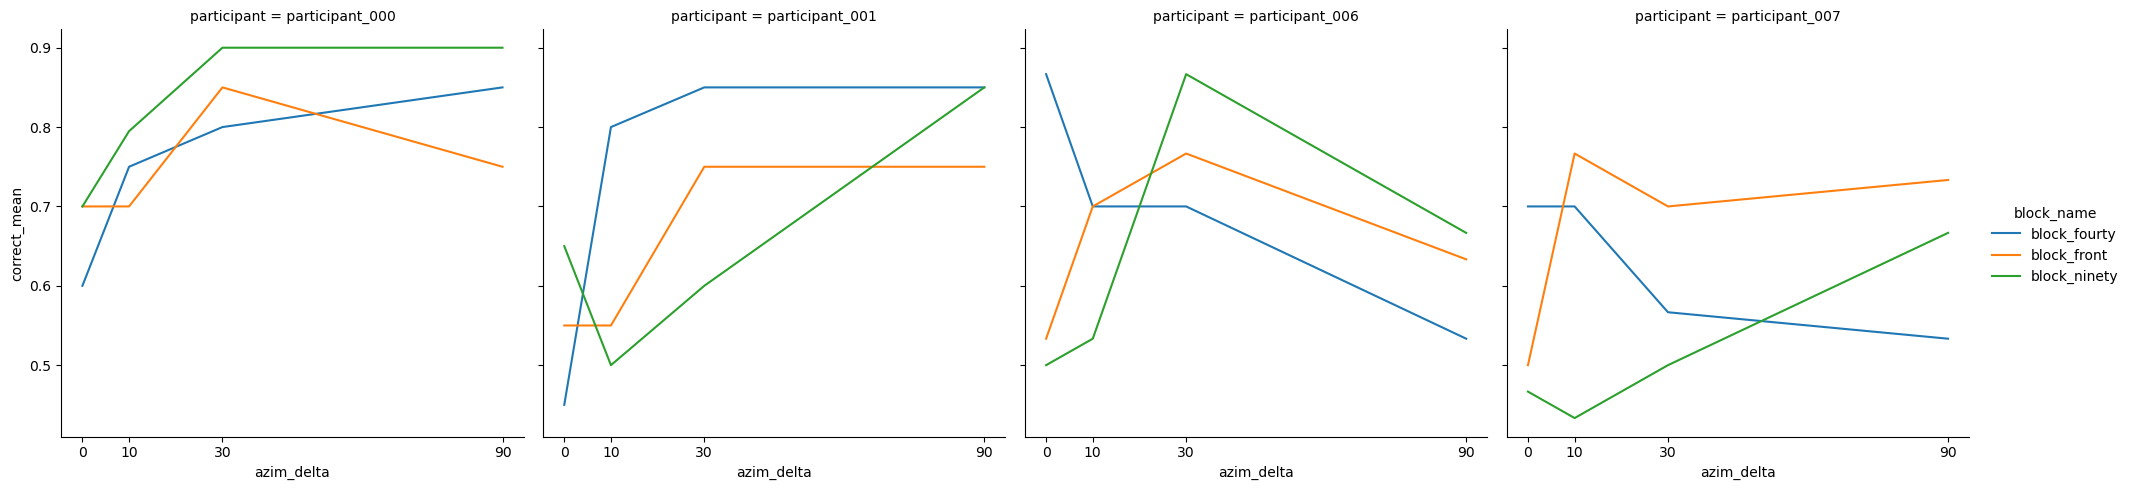

In [65]:
g = sns.relplot(data=results_summary, x='azim_delta', y='correct_mean', hue='block_name',
                 errorbar=('se', 1),err_style='bars',
                 col='participant',
                  kind='line', aspect=1)
# set xticks to be the same as the azimuth deltas
g.set(xticks=results_summary['azim_delta'].unique())